Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Settings

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

Load data

In [4]:
features = pd.read_csv("../data/civ5_features.csv")
clusters = pd.read_csv("../data/civ5_clusters.csv")
features = features.merge(clusters, on="leader_name")

Constants

In [5]:
CLUSTER_LABELS = {
    0: "Diplomatic builders",
    1: "Scientific conquerors",
    2: "Aggressive warmongers",
    3: "Peaceful culturalists",
    4: "Wonder seekers"
}
CLUSTER_COLORS = ["#2ecc71", "#e74c3c", "#e67e22", "#3498db", "#9b59b6"]

FEATURE_NAMES = {
    "warrior": "Aggressiveness",
    "WarmongerHate": "Pacifism",
    "WonderCompetitiveness": "Wonder building",
    "VictoryCompetitiveness": "Victory drive",
    "Loyalty": "Loyalty",
    "MinorCivCompetitiveness": "City-state competition",
    "friendliness": "Friendliness",
    "deceptiveness": "Deceptiveness",
    "minor_ignore": "City-state indifference",
    "naval": "Naval focus",
    "defense": "Defensiveness",
    "science": "Science focus",
    "EXPANSION": "Expansion drive",
    "GROWTH": "City growth",
    "WONDER": "Wonder priority",
    "CULTURE": "Cultural focus",
    "RELIGION": "Religious focus",
    "DIPLOMACY": "Diplomacy focus"
}

RADAR_FEATURES = {
    "Naval focus":        "naval",
    "Aggressiveness":     "warrior",
    "Victory drive":      "VictoryCompetitiveness",
    "Expansion drive":    "EXPANSION",
    "Deceptiveness":      "deceptiveness",
    "Science focus":      "science",
    "Wonder priority":    "WONDER",
    "Defensiveness":      "defense",
    "Cultural focus":     "CULTURE",
    "City growth":        "GROWTH",
    "Religious focus":    "RELIGION",
    "Friendliness":       "friendliness",
    "Pacifism":           "WarmongerHate",
    "Loyalty":            "Loyalty",
    "Diplomacy focus":    "DIPLOMACY",
}

features["cluster_name"] = features["cluster"].map(CLUSTER_LABELS)

Summary table

In [6]:
feature_cols = [c for c in features.columns
                if c not in ["leader_name", "cluster", "cluster_name", "city_state_stance"]
                and features[c].dtype in ["float64", "int64"]]

def rename_features(feature_str):
    return ", ".join([FEATURE_NAMES.get(f.strip(), f.strip())
                      for f in feature_str.split(",")])

rows = []
for _, row in features.iterrows():
    values = row[feature_cols].astype(float)
    top3 = values.nlargest(3).index.tolist()
    bot3 = values.nsmallest(3).index.tolist()
    rows.append({
        "leader": row["leader_name"],
        "cluster": row["cluster_name"],
        "top features": rename_features(", ".join(top3)),
        "low features": rename_features(", ".join(bot3))
    })

summary = pd.DataFrame(rows).sort_values(["cluster", "leader"])

for cluster_name in sorted(summary["cluster"].unique()):
    print(f"\n{'='*60}")
    print(f"{cluster_name}")
    print(f"{'='*60}")
    sub = summary[summary["cluster"] == cluster_name][["leader", "top features", "low features"]]
    print(sub.to_string(index=False))


Aggressive warmongers
      leader                                     top features                                                   low features
Ashurbanipal   Aggressiveness, Science focus, Expansion drive                 City-state competition, Pacifism, Friendliness
       Askia Wonder building, Religious focus, Aggressiveness                       Deceptiveness, Wonder priority, Pacifism
      Attila     Deceptiveness, Aggressiveness, Victory drive              Pacifism, Wonder building, City-state competition
    Boudicca   Religious focus, Cultural focus, Victory drive                        Friendliness, Pacifism, Wonder building
        Dido        Deceptiveness, Naval focus, Victory drive                     Wonder priority, Pacifism, Wonder building
 GenghisKhan          Victory drive, Expansion drive, Loyalty City-state competition, Deceptiveness, City-state indifference
      Harald             Naval focus, Loyalty, Aggressiveness                Wonder building, Victory 

Top/bottom leaders par feature

In [7]:
n = 3

for col, label in FEATURE_NAMES.items():
    if col not in features.columns:
        continue
    top = features.nlargest(n, col)[["leader_name", col, "cluster_name"]]
    bot = features.nsmallest(n, col)[["leader_name", col, "cluster_name"]]

    top = top.rename(columns={"leader_name": "Leader", col: label, "cluster_name": "Cluster"})
    bot = bot.rename(columns={"leader_name": "Leader", col: label, "cluster_name": "Cluster"})

    print(f"\n{'='*55}")
    print(f"{label}")
    print(f"{'='*55}")
    print(f"  Top {n}:")
    print(top.to_string(index=False))
    print(f"  Bottom {n}:")
    print(bot.to_string(index=False))


Aggressiveness
  Top 3:
   Leader  Aggressiveness               Cluster
   Attila             7.6 Aggressive warmongers
    Shaka             7.4 Aggressive warmongers
Montezuma             7.2 Aggressive warmongers
  Bottom 3:
  Leader  Aggressiveness               Cluster
  Gandhi             3.0 Peaceful culturalists
Hiawatha             3.2   Diplomatic builders
  Darius             3.4        Wonder seekers

Pacifism
  Top 3:
      Leader  Pacifism               Cluster
Ramkhamhaeng         8 Peaceful culturalists
    Selassie         8 Peaceful culturalists
     Casimir         7   Diplomatic builders
  Bottom 3:
   Leader  Pacifism               Cluster
Montezuma         1 Aggressive warmongers
Alexander         2 Scientific conquerors
   Attila         3 Aggressive warmongers

Wonder building
  Top 3:
        Leader  Wonder building               Cluster
      Ramesses                9        Wonder seekers
         Askia                8 Aggressive warmongers
Nebuchadnezzar  

Radar chart

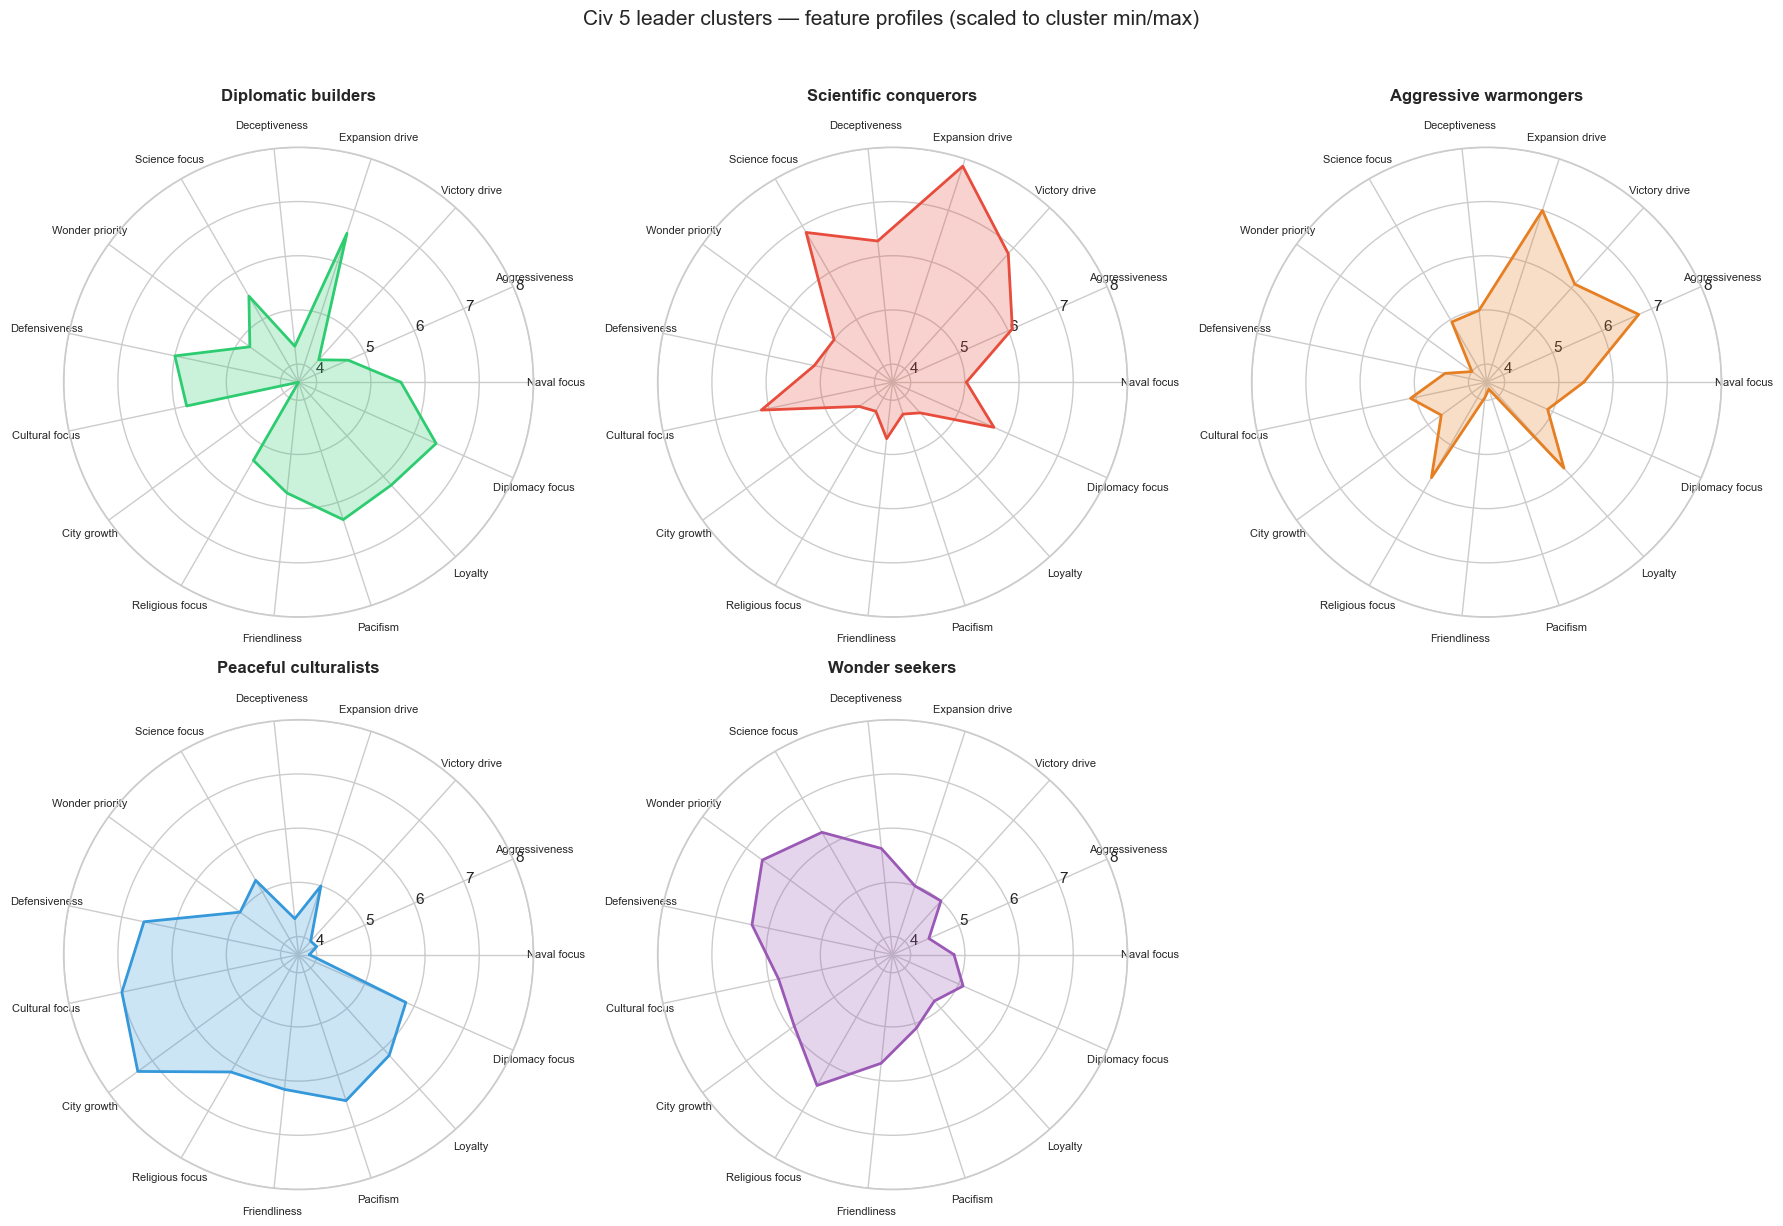

In [15]:
labels = list(RADAR_FEATURES.keys())
cols   = list(RADAR_FEATURES.values())
N      = len(labels)

cluster_profiles = (features
                    .drop(columns=["leader_name", "cluster_name"])
                    .groupby("cluster")
                    .mean(numeric_only=True)[cols])

y_min = cluster_profiles.min().min() 
y_max = cluster_profiles.max().max()

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, (cluster_id, label) in enumerate(CLUSTER_LABELS.items()):
    ax = axes[idx]
    values = cluster_profiles.loc[cluster_id, cols].tolist()
    values += values[:1]

    ax.plot(angles, values, color=CLUSTER_COLORS[cluster_id], linewidth=2)
    ax.fill(angles, values, color=CLUSTER_COLORS[cluster_id], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=8)
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(np.arange(round(y_min), round(y_max) + 1, 1))
    ax.set_title(label, size=12, fontweight="bold", pad=15)
    ax.grid(True)

axes[-1].set_visible(False)
fig.suptitle("Civ 5 leader clusters — feature profiles (scaled to cluster min/max)",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("../figures/radar_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

Heatmap

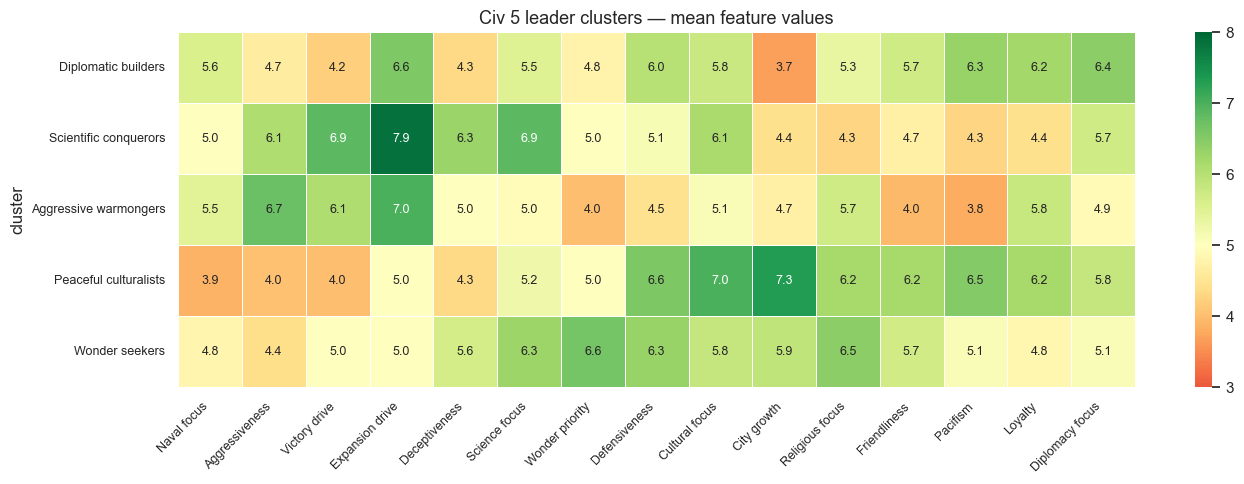

In [9]:
col_order   = list(RADAR_FEATURES.values())
label_order = list(RADAR_FEATURES.keys())

cluster_profiles = (features
                    .drop(columns=["leader_name", "cluster_name"])
                    .groupby("cluster")
                    .mean(numeric_only=True)
                    .round(2))

cluster_profiles_readable = (cluster_profiles[col_order]
                              .rename(columns=dict(zip(col_order, label_order)),
                                      index=CLUSTER_LABELS))

plt.figure(figsize=(14, 5))
sns.heatmap(cluster_profiles_readable,
            annot=True, fmt=".1f",
            cmap="RdYlGn",
            center=5,
            vmin=3, vmax=8,
            linewidths=0.5,
            annot_kws={"size": 9})
plt.title("Civ 5 leader clusters — mean feature values", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("../figures/heatmap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()